c:\Users\sangh\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


현재 연산에 사용 중인 디바이스: cpu


c:\Users\sangh\Documents\ax_study\04_MACHINE_LEARNING\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sangh\.cache\huggingface\hub\models--monologg--kobert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
[transformers] A new version of the following files was downloaded from https://huggingface.c

--- 분석 결과 ---
  Emotion  Probability
0      분노     0.197157
1      불안     0.184516
2      기쁨     0.164421
3      평온     0.192148
4      슬픔     0.261757


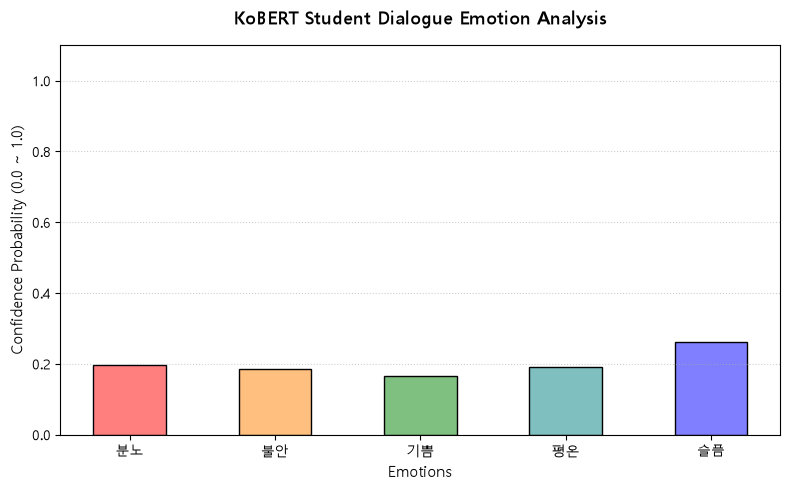

In [1]:
import platform
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

# 가속 연산 디바이스(GPU/MPS) 자동 설정
# CUDA(NVIDIA) -> MPS(Mac 인텔/실리콘) -> CPU 순으로 사용 가능한 자원을 체크합니다.
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu"
)
print(f"현재 연산에 사용 중인 디바이스: {device}")

# matplotlib 한글 깨짐 방지 설정 
if platform.system() == 'Darwin':      # macOS 환경
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':   # Windows 환경
    rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


# 사전 학습된 KoBERT 감정 분류 모델 및 토크나이저 로드
model_name = "rkdaldus/ko-sent5-classification"
tokenizer = AutoTokenizer.from_pretrained("monologg/kobert", trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained(model_name,).to(device)

# 분석 대상 입력 텍스트 정의
text_to_analyze = "이번 시험을 위해 밤을 새우며 정말 열심히 준비했는데 생각보다 점수가 너무 낮게 나와서 속상하고 눈물이 나네"

# 텍스트 토큰화 및 PyTorch 텐서 변환
encoded_inputs = tokenizer(text_to_analyze, return_tensors="pt", padding=True, truncation=True).to(device)

# 모델 추론을 통한 로짓(Logits) 값 추출
with torch.no_grad():
    model_outputs = model(**encoded_inputs)
    logits = model_outputs.logits

# Softmax 함수를 적용하여 감정별 확률 계산
calculated_probabilities = torch.nn.functional.softmax(logits, dim=-1).squeeze().tolist()

# 감정 레이블 매핑 및 데이터프레임 변환
emotion_labels = ["분노", "불안", "기쁨", "평온", "슬픔"]
emotion_df = pd.DataFrame({
    "Emotion": emotion_labels,
    "Probability": calculated_probabilities
})

print("--- 분석 결과 ---")
print(emotion_df)

# 분석 결과 시각화 (막대그래프)
plt.figure(figsize=(8, 5))
bar_colors = ["#ff7f7f", "#ffbf7f", "#7fbf7f", "#7fbfbf", "#7f7fff"]
plt.bar(emotion_df["Emotion"], emotion_df["Probability"], color=bar_colors, edgecolor="black", width=0.5)

plt.title("KoBERT Student Dialogue Emotion Analysis", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Emotions", fontsize=11)
plt.ylabel("Confidence Probability (0.0 ~ 1.0)", fontsize=11)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [2]:
from transformers import PreTrainedTokenizerFast, BartForConditionalGeneration

# KoBART 요약 모델 및 전용 토크나이저 로드
kobart_identifier = "gogamza/kobart-summarization"
bart_tokenizer = PreTrainedTokenizerFast.from_pretrained(kobart_identifier)
bart_model = BartForConditionalGeneration.from_pretrained(kobart_identifier).to(device)

# 요약 대상 원문 텍스트 정의
naver_news = (
    "최근 대학가에서는 태풍과 급격한 폭염의 장기화로 인해 대면 야외 수업 및 야외 축제 일정을 전면 수정하고 있습니다. "
    "특히 학생들이 준비했던 야외 엠티와 야외 부스 행사 등이 폭우로 인해 전격 취소되거나 실내 세미나실 행사로 전격 전환되고 있습니다. "
    "대학 연합 축제 준비위원회는 학생 안전 확보를 최우선으로 지정하고 실시간 기상 경보 문자 연동 스크립트를 개발해 비상 체계를 구축했습니다."
)

# 텍스트 인코딩 및 토큰화
input_ids = bart_tokenizer.encode(naver_news, return_tensors="pt", max_length=1024, truncation=True).to(device)

# 요약문 생성 (Beam Search 및 반복 방지 옵션 적용)
summary_tokens = bart_model.generate(
    input_ids,
    max_length=80,
    min_length=35,
    num_beams=5,
    no_repeat_ngram_size=3,
    early_stopping=True
)

# 생성된 토큰 디코딩
summarized_result = bart_tokenizer.decode(summary_tokens, skip_special_tokens=True)
print("--- 요약 결과 ---")
print(f"요약문: {summarized_result}")

Loading weights: 100%|██████████| 260/260 [00:00<00:00, 6074.20it/s]


--- 요약 결과 ---
요약문: ['최근 대학가에서는 태풍과 급격한 폭염의 장기화로 인해 대면 야외 수업 및 야외 축제 일정을 전면 수정하고 학생들이 준비했던 야외 엠티와 야외 부스 행사 등이 폭우로 인해 전격 취소되거나 실내 세미나실 행사로 전격 전환되고 있고, 대학 연합 축제 준비위원회는 학생 안전 확보를 최우선으로 지정하고 실시간 기상 경보 문자 연동 스크립트를 개발해 비상 체계를 구축했습니다.']


In [5]:
from transformers import pipeline
import torch

# Gemma 인스트럭션 모델 식별자 설정
gemma_identifier = "google/gemma-2b-it"

# 텍스트 생성 파이프라인 구축 (bfloat16 연산 및 자원 자동 배치 적용)
gemma_generator = pipeline(
    "text-generation",
    model=gemma_identifier,
    dtype=torch.bfloat16,
    device_map="auto" # accelerate를 통해 OS별 하드웨어(CUDA/MPS) 최적 자동 할당
)

# 대화형 프롬프트 구조 정의
user_dialogue = [
    {"role": "user", "content": "머신러닝과 딥러닝의 핵심 차이점을 비전공자 대학생에게 딱 한 문장으로 비유해서 알려줘."}
]

# 답변 생성
generation_outputs = gemma_generator(user_dialogue, max_new_tokens=200)

# 최종 답변 추출 및 출력
ai_reply = generation_outputs[0]["generated_text"][-1]["content"]
print("--- Gemma 답변 ---")
print(f"Gemma의 답변:\n{ai_reply}")

OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/gemma-2b-it.
401 Client Error. (Request ID: Root=1-6a97c950-1f152bed26e01e1972b35295;ede3767c-a5ad-4637-84f8-0f55e9d41cae)

Cannot access gated repo for url https://huggingface.co/google/gemma-2b-it/resolve/main/config.json.
Access to model google/gemma-2b-it is restricted. You must have access to it and be authenticated to access it. Please log in.